In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Análisis exploratorio de datos

In [24]:
df_diabetes = pd.read_csv("./diabetes.csv")
df_diabetes.head()

,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0,6,148,72.0,35.0,0.0,33.6,0.627,50,1
1,1,1,85,66.0,29.0,0.0,26.6,0.351,31,0
2,2,8,183,64.0,0.0,0.0,23.3,0.672,32,1
3,3,1,89,66.0,23.0,94.0,28.1,0.167,21,0
4,4,0,137,40.0,35.0,168.0,43.1,2.288,33,1


In [25]:
# Eliminamos la columna "Unnamed: 0", que es solo un índice residual del csv y no aporta información
df_diabetes = df_diabetes.drop(columns=["Unnamed: 0"])
df_diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35.0,0.0,33.6,0.627,50,1
1,1,85,66.0,29.0,0.0,26.6,0.351,31,0
2,8,183,64.0,0.0,0.0,23.3,0.672,32,1
3,1,89,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137,40.0,35.0,168.0,43.1,2.288,33,1


In [26]:
print("Número de instancias:", df_diabetes.shape[0])
print("Número total de columnas:", df_diabetes.shape[1])
print("Número de atributos predictores:", df_diabetes.shape[1] - 1)

Número de instancias: 768
Número total de columnas: 9
Número de atributos predictores: 8


- ¿Cuál es la variable objetivo (target) y qué representa cada uno de sus valores?

    La *variable objetivo* (target) es la variable **"Outcome"**, y sus variables 1 y 0 representan si la paciente presenta o no diabetes respectivamente 
- ¿Qué representa cada **fila** del dataset?

    Cada **fila** del dataset representa a una paciente distinta
- ¿Qué representa cada **columna**?

    Cada una de las **columnas** del dataset representa una variable clínica distinta, estas pueden ser: número de embarazos, nivel de glucosa en sangre, presión arterial, nivel de insulina, edad, entre otras.

- ¿Qué tipo de problema de aprendizaje automático es este: **clasificación** o **regresión**? Justificá por qué.

    Este dataset representa un **problema de clasificación**. Esto se debe a que la variable objetivo, "Outcome", no es una medida continua sino una etiqueta categórica que solo puede tomar dos valores posibles: 0 (paciente sin diabetes) o 1 (paciente con diabetes). El objetivo del modelo no es predecir una cantidad (como ocurriría en un problema de regresión, por ej. al estimar el precio de una vivienda), sino determinar a cuál de dos clases mutuamente excluyentes pertenece cada paciente en función de sus mediciones clínicas (glucosa, presión arterial, BMI, edad, etc.). Además, aunque Outcome esté codificado numéricamente (0 y 1), estos números no representan una escala ordinal ni una cantidad, ya que no existe un valor intermedio entre tener y no tener diabetes, lo cual confirma que es categórica y, por lo tanto, que se trata de un problema de clasificación

## 2. Exploración inicial de los datos

Observamos los atributos existentes y el numero de instancias de cada uno

In [27]:
df_diabetes.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             767 non-null    float64
 3   SkinThickness             756 non-null    float64
 4   Insulin                   763 non-null    float64
 5   BMI                       767 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(5), int64(4)
memory usage: 54.1 KB


**Observamos las categorias de los atributos categorico**

In [28]:
df_diabetes["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

- ¿Qué tipos de datos aparecen en el dataset (enteros, flotantes, etc.)? ¿Hay columnas categóricas?
    En el dataset aparecen datos enteros y flotantes. La unica columna categorica es "Outcome", que indica si tiene o no diabetes el paciente

**Analizamos si hay valores faltantes**

In [29]:
df_diabetes.isnull().sum() #Se cuentan todos los NaN por columna, para ver si hay valores faltantes en el dataset

Pregnancies                  0
Glucose                      0
BloodPressure                1
SkinThickness               12
Insulin                      5
BMI                          1
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64

- ¿Existen valores faltantes (NaN) en el dataset? 
    Como se observa las columnas "BloodPressure", "SkinThinckness", "Insulin" y "BMI" presentan valores faltantes

**Resumen estadistico de los atributos numericos**

In [30]:
df_diabetes.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,767.000000,756.000000,763.000000,767.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.195567,20.862434,80.322412,32.034289,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.206609,15.865314,115.439459,7.804050,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,36.000000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,128.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [31]:
df_diabetes.median() #Se obtiene un resumen estadístico de las columnas num

Pregnancies                   3.0000
Glucose                     117.0000
BloodPressure                72.0000
SkinThickness                23.0000
Insulin                      36.0000
BMI                          32.0000
DiabetesPedigreeFunction      0.3725
Age                          29.0000
Outcome                       0.0000
dtype: float64

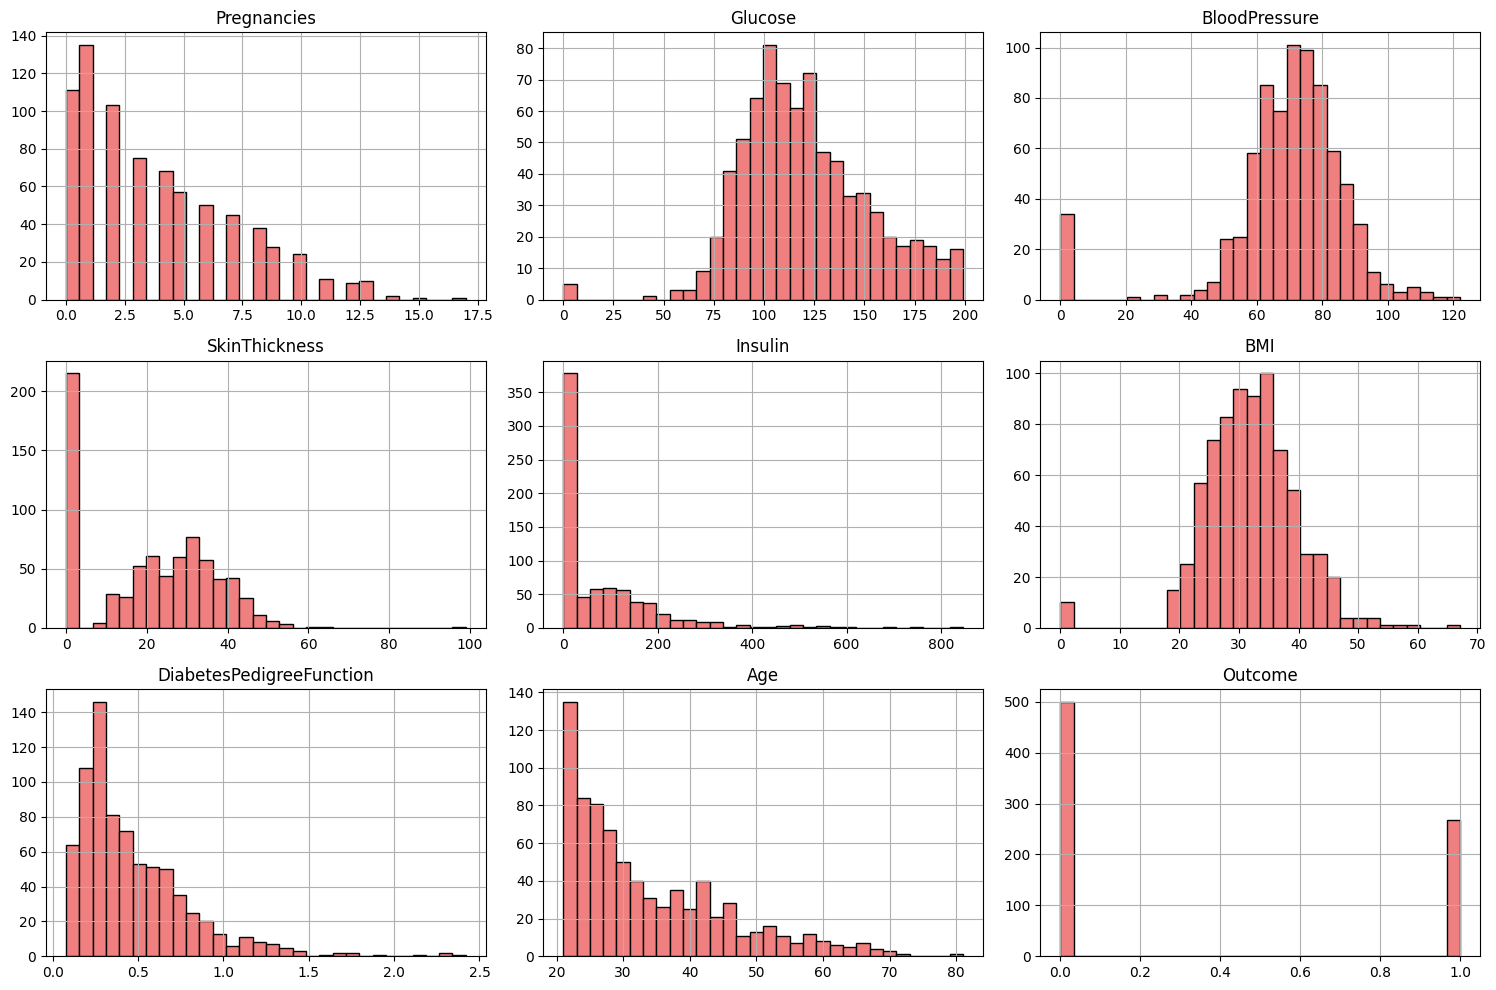

In [32]:
df_diabetes.hist(bins=30, figsize=(15, 10), edgecolor="k", color= "lightcoral") #Genera histogramas para cada atributo del dataset
plt.tight_layout()
plt.show()

- ¿Existen variables con **distribuciones sesgadas**? ¿Cuáles y hacia qué lado?
    Como se observa en los histogramas, las variables Pregnancies, Age, DiabetesPedigreeFuction e Insulin presentan una **distribucion sesgada** hacia la derecha. 

- ¿Existen variables con **escalas muy diferentes** entre sí? 
    Si existen **escalas muy diferentes** entre si, como se observa en la variable target Outcome ya que tiene datos solo en 0 o 1 

## 3. División del dataset en entrenamiento y prueba

Se deben separar los datos en dos partes debido a que, de esta manera es posible conocer si el modelo realmente aprendió a partir de los datos. Si entrenáramos y evaluáramos con los mismos datos, no sabríamos si el modelo realmente aprendió el patrón clínico de la diabetes o si simplemente "memorizó" esos casos puntuales.

In [33]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    df_diabetes, test_size=0.2, stratify=df_diabetes["Outcome"], random_state=42
)

print("Train:", train_set.shape)
print("Test:", test_set.shape)
print()
print("Proporción de Outcome en train:")
print(train_set["Outcome"].value_counts(normalize=True))
print()
print("Proporción de Outcome en test:")
print(test_set["Outcome"].value_counts(normalize=True))

Train: (614, 9)
Test: (154, 9)

Proporción de Outcome en train:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Proporción de Outcome en test:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


Para dividir los datos se utilizó **train_test_split** con un test_size de 0.2, reservando el **20%** de las pacientes para el conjunto de **prueba** y el **80%** para **entrenamiento**. Como la variable "Outcome" presenta un desbalance de clases (65% sin diabetes, 35% con diabetes), se aplicó **muestreo estratificado** (stratify=Outcome) para garantizar que ambos subconjuntos (entrenamiento y prueba) mantuvieran una proporción similar de pacientes con y sin diabetes, evitando así que el azar generara una división poco representativa. Se fijó además random_state=42 para asegurar la reproducibilidad del split

A partir de esta sección solo **vamos a trabajar con train_set**, los datos en test_set se van a guardar y soló serán utilizados cuando se evalue el modelo

In [34]:
# Hacemos una copia de trabajo del conjunto de entrenamiento
diabetes_train = train_set.copy()

 ## 4. Análisis de posibles problemas en los datos

In [35]:
invalid_zero_col = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"] # Columnas donde no se esperan valores cero

zero_counts = (diabetes_train[invalid_zero_col] == 0).sum() #numero de ceros por columna

print("Ceros detectados en columnas médicas que no pueden ser cero en condiciones reales:")
for col in invalid_zero_col:
    print(f" - {col}: {zero_counts[col]}")

print("\nCeros por Outcome:")
zero_outcome = diabetes_train.groupby("Outcome")[invalid_zero_col].apply(lambda g: (g == 0).sum())
print(zero_outcome)


Ceros detectados en columnas médicas que no pueden ser cero en condiciones reales:
 - Glucose: 4
 - BloodPressure: 22
 - SkinThickness: 164
 - Insulin: 285
 - BMI: 8

Ceros por Outcome:
         Glucose  BloodPressure  SkinThickness  Insulin  BMI
Outcome                                                     
0              2             11            102      182    7
1              2             11             62      103    1


Las variables **Glucose, BloodPressure, SkinThinkness, Insulin y BMI** no pueden tomar valores cero y es por ello que si toman ese valor se considera que es una error o dato faltante ya que son *variables invalidas, no mediciones reales*.
Para poder tratar estos errores podemos **convertir esos ceros en NAN** e **imputarlos utilizando mediana global** ya que si lo hacemos la imputacion utilizando Outcome, se complica al agregar un nuevo paciente y ademas hay una fuga de informacion al momento de validacion o prueba.

A continuación se muestra la **estrategia de imputación condicionada por Outcome**:

In [36]:
# Calculamos las medianas por grupo de Outcome
medianas_outcome = diabetes_train.groupby("Outcome")[invalid_zero_col].median()
print("\nMedianas por Outcome:")
print(medianas_outcome)

# Crea una copia para la imputación condicionada
diabetes_train_imputacion_cond = diabetes_train.copy()

# Convertimos ceros en NaN primero
for col in invalid_zero_col:
    diabetes_train_imputacion_cond.loc[diabetes_train_imputacion_cond[col] == 0, col] = np.nan

# Imputamos usando medianas por Outcome
for outcome_value in diabetes_train_imputacion_cond["Outcome"].unique():
    mask = diabetes_train_imputacion_cond["Outcome"] == outcome_value
    for col in invalid_zero_col:
        median_val = medianas_outcome.loc[outcome_value, col]
        diabetes_train_imputacion_cond.loc[mask, col] = diabetes_train_imputacion_cond.loc[mask, col].fillna(median_val)

print("\nDatos después de imputación condicionada:")
print(diabetes_train_imputacion_cond[invalid_zero_col].describe())



Medianas por Outcome:
         Glucose  BloodPressure  SkinThickness  Insulin   BMI
Outcome                                                      
0          108.0           70.0           22.0     42.0  30.1
1          141.0           74.0           28.0     56.0  34.3

Datos después de imputación condicionada:
          Glucose  BloodPressure  SkinThickness     Insulin         BMI
count  614.000000     614.000000     614.000000  614.000000  614.000000
mean   121.719870      72.136808      27.701954  100.897394   32.428176
std     30.031843      12.281268       9.280165   93.157172    6.829521
min     56.000000      24.000000       7.000000   15.000000   18.200000
25%     99.000000      64.000000      22.000000   42.000000   27.625000
50%    117.000000      72.000000      28.000000   56.000000   32.400000
75%    141.000000      80.000000      32.000000  130.000000   36.500000
max    199.000000     122.000000      99.000000  744.000000   67.100000


Ahora, hacemos la **estrategia de imputación global**:

In [37]:
# Calcular medianas globales del conjunto de entrenamiento
medianas_global = diabetes_train[invalid_zero_col].median()
print("\nMedianas globales:")
print(medianas_global)

# Crear una copia para la imputación global
diabetes_train_imput_global = diabetes_train.copy()

# Convertir ceros en NaN
for col in invalid_zero_col:
    diabetes_train_imput_global.loc[diabetes_train_imput_global[col] == 0, col] = np.nan

# Imputar usando medianas globales
for col in invalid_zero_col:
    diabetes_train_imput_global[col] = diabetes_train_imput_global[col].fillna(medianas_global[col])
    
print("\nDatos después de imputación global:")
print(diabetes_train_imput_global[invalid_zero_col].describe())

print("\nMedianas globales para aplicar en test y nuevos datos:")
print(medianas_global)


Medianas globales:
Glucose          117.0
BloodPressure     72.0
SkinThickness     23.0
Insulin           43.0
BMI               32.3
dtype: float64

Datos después de imputación global:
          Glucose  BloodPressure  SkinThickness     Insulin         BMI
count  614.000000     614.000000     614.000000  614.000000  614.000000
mean   121.671010      72.140065      27.332248   98.975570   32.446743
std     30.003794      12.275119       9.303670   94.171173    6.824142
min     56.000000      24.000000       7.000000   15.000000   18.200000
25%     99.000000      64.000000      23.000000   43.000000   27.625000
50%    117.000000      72.000000      23.000000   43.000000   32.300000
75%    140.000000      80.000000      32.000000  130.000000   36.500000
max    199.000000     122.000000      99.000000  744.000000   67.100000

Medianas globales para aplicar en test y nuevos datos:
Glucose          117.0
BloodPressure     72.0
SkinThickness     23.0
Insulin           43.0
BMI              

La ventaja de esta estrategia es que usa una **única mediana calculada** del conjunto de entrenamiento, ademas que se puede **usar si hay nuevos pacientes**. Y es aplicable para el entrenamiento y la validacion ya que no hay fuga de información

Comparamos las estrategias:


Diferencias (Condicional - Global):
          Glucose  BloodPressure  SkinThickness     Insulin         BMI
count  614.000000     614.000000     614.000000  614.000000  614.000000
mean     0.048860      -0.003257       0.369707    1.921824   -0.018567
std      1.463272       0.387390       1.664854    5.054717    0.260719
min     -9.000000      -2.000000      -1.000000   -1.000000   -2.200000
25%      0.000000       0.000000       0.000000   -1.000000    0.000000
50%      0.000000       0.000000       0.000000    0.000000    0.000000
75%      0.000000       0.000000       0.000000    0.000000    0.000000
max     24.000000       2.000000       5.000000   13.000000    2.000000


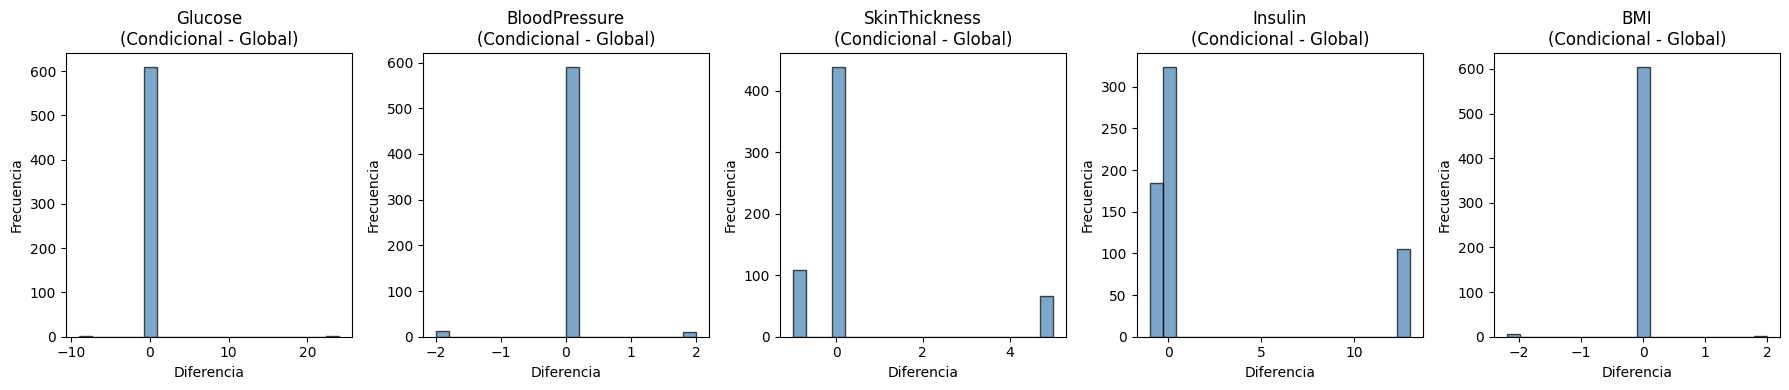

In [38]:
diferencias = diabetes_train_imputacion_cond[invalid_zero_col] - diabetes_train_imput_global[invalid_zero_col]
print("\nDiferencias (Condicional - Global):")
print(diferencias.describe())

# 4. Visualizar diferencias
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for idx, col in enumerate(invalid_zero_col):
    axes[idx].hist(diferencias[col].dropna(), bins=20, edgecolor='k', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col}\n(Condicional - Global)')
    axes[idx].set_xlabel('Diferencia')
    axes[idx].set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Observando estas visualización podemos ver que la **mejor estrategia de imputación** es la que utiliza **medianas globales**, debido a que en las variables SkinThickness e Insulin difieren en los valores ya que presenta barras que no estan en cero con mayor diferenciacion que las otras variables.

Si las dos imputaciones dieran el mismo valor en la mayoria de los caso, se observaria la barra en cero unicamente.

## 5. Representación de los datos

Analizamos la distribución de la variable Outcome

Conteo de Outcome:
Outcome
0    500
1    268
Name: count, dtype: int64

Porcentaje de Outcome:
Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64


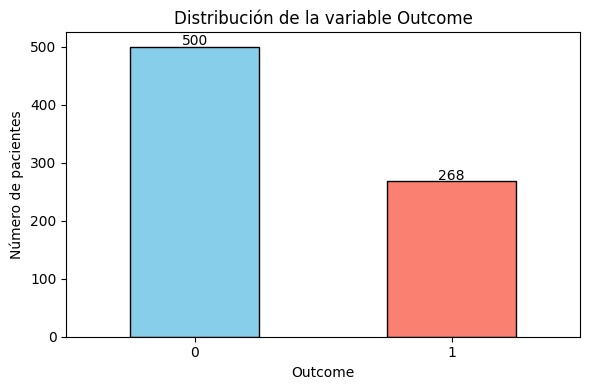

In [ ]:
outcome_cont = df_diabetes["Outcome"].value_counts().sort_index() #contamos la cantidad de pacientes con y sin diabetes
outcome_por = df_diabetes["Outcome"].value_counts(normalize=True).sort_index() * 100 #calculamos el porcentaje

print("Conteo de Outcome:")
print(outcome_cont)
print("\nPorcentaje de Outcome:")
print(outcome_por.round(2))

#Graficamos la distribución de la variable Outcome
plt.figure(figsize=(6, 4))
outcome_cont.plot(kind="bar", color=["skyblue", "salmon"], edgecolor="k")
plt.title("Distribución de la variable Outcome")
plt.xlabel("Outcome")
plt.ylabel("Número de pacientes")
plt.xticks(rotation=0)
for i, v in enumerate(outcome_cont):
    plt.text(i, v + 3, str(v), ha="center")
plt.tight_layout()
plt.show()

Como se observa en el porcentaje y en la grafica, **las clases no estan balanceadas** ya que hay mas pacientes sin diabetes que aquellos con diabetes.

# Preparacion de los Datos

In [40]:
print(df_diabetes.head())
print(df_diabetes.info())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0           35.0      0.0  33.6   
1            1       85           66.0           29.0      0.0  26.6   
2            8      183           64.0            0.0      0.0  23.3   
3            1       89           66.0           23.0     94.0  28.1   
4            0      137           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

In [41]:
if "Unnamed: 0" in df_diabetes.columns or df_diabetes.columns[0] == "":
    df_diabetes = df_diabetes.loc[:, ~df_diabetes.columns.str.contains('^Unnamed')]

In [42]:
X = df_diabetes.drop(columns=['Outcome'])
y = df_diabetes['Outcome']

In [43]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')